## Basics

In [1]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 14.63it/s]


Numba compilation complete!
0.23.7


In [9]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20251014"

# filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_ASO = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\DATA\\Web digitizer\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarfalling\\images\\"
newfile2 = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025fallingtoosarcomp\\"
files2 = os.listdir(newfile2)

In [4]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [58]:
def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def MBONnamefile(MBONList, pathfile):
    #reading mbonlist file

    #MBONFILEDIRECTORY: specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
    directorynew = os.path.dirname(os.path.dirname(pathfile)) #goes up one directory
    fileinnewdirc = os.listdir(directorynew)

    for file_no2 in fileinnewdirc:
        if ".csv" in file_no2:
            ff = os.path.join(directorynew, file_no2)
            csvfile = pd.read_csv(ff)

    csvfile = csvfile.astype('string')

    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

    lobelocation = pd.DataFrame()

    for m in MBONList:
        lobeloc = pd.DataFrame()
        lobeloc['MBON'] = [m]
        loclst = find_number(csvfile, m, "Lobe")
        mbonlst = find_number(csvfile, m, "MBON number").strip()
        ntlst = find_number(csvfile, m, "Neurotransmitter")
        lobeloc['Lobe_location'] = [loclst]
        lobeloc['MBON number'] = [mbonlst]
        lobeloc['Neurotransmitter'] = [ntlst]
        
        lobelocation = pd.concat([lobelocation, lobeloc])

    lobelocation = lobelocation.reset_index(drop=True)
    return lobelocation

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

import textwrap

def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc

def matchingcomp(dfreg_Cr2, osar_multiplot_cr2):
    matchingset = list(set(dfreg_Cr2['MBON']) & set(osar_multiplot_cr2['MBON']))
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = dfreg_Cr2[(dfreg_Cr2['MBON'] == n)]
        df_b = pd.merge(df_a, osar_multiplot_cr2, on = "MBON" )
        newdf_a = pd.concat([newdf_a, df_b]).reset_index(drop=True)


def forestplot_multiplot(sorteddf, df1, parameter):
    lst = []
    names =[]
    for n in sorteddf['MBON']:
        tempdf1 = df1[(df1['MBON'] == n)].reset_index(drop=True)
        dbfeature = dabest.load(tempdf1, idx=("Sibling", "Offspring"),x="status", y= parameter)
        lst.append(dbfeature)
        names.append(n)
    return lst, names


## Formulas to run


In [7]:
#mbon locations
MBONList = []
for yy in files2:
    MBONList.append(yy.split(" ")[0])

MBONList = list(set(MBONList))

lobelocation = MBONnamefile(MBONList, specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\")

## Comparison of Aso and me OSAR

In [232]:
webdigitizer= os.listdir(filedirectory_ASO)

asofile = pd.read_csv(os.path.join(filedirectory_ASO, next(f for f in os.listdir(filedirectory_ASO) if f.endswith(".csv"))), header=0).fillna("")

aso_corrected = asofile.drop(columns=['PI', 'LAI'])

In [ ]:
conditions = ['Eighth','Quarter','Half', 'Full']
totalcompmodelslst = []

for x in conditions:
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + x +".xlsx")
    comparisonmodel = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"][['MBON','PI_Δg_OSAR','Light Attraction Index_Δg_OSAR']]
    comparisonmodel = comparisonmodel.rename(columns={'PI_Δg_OSAR': 'PI_Δg_OSAR_' + x,'Light Attraction Index_Δg_OSAR': 'Light Attraction Index_Δg_OSAR_' + x })
    print(comparisonmodel)
    totalcompmodelslst.append(comparisonmodel)
        
totalcompmodel = totalcompmodelslst[0]
for p in totalcompmodelslst[1:]:
    totalcompmodel = pd.merge(totalcompmodel, p, on='MBON', how='inner')


In [188]:
# totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")
# comparisonmodel = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"][['MBON','PI_Δg_OSAR','Light Attraction Index_Δg_OSAR']]
asovsme = pd.DataFrame()
asovsme =totalcompmodel.merge(aso_corrected, on = "MBON", how = "inner").reset_index(drop=True)
asovsme

asovsme.columns = asovsme.columns.str.replace("Light Attraction Index", "LAI")

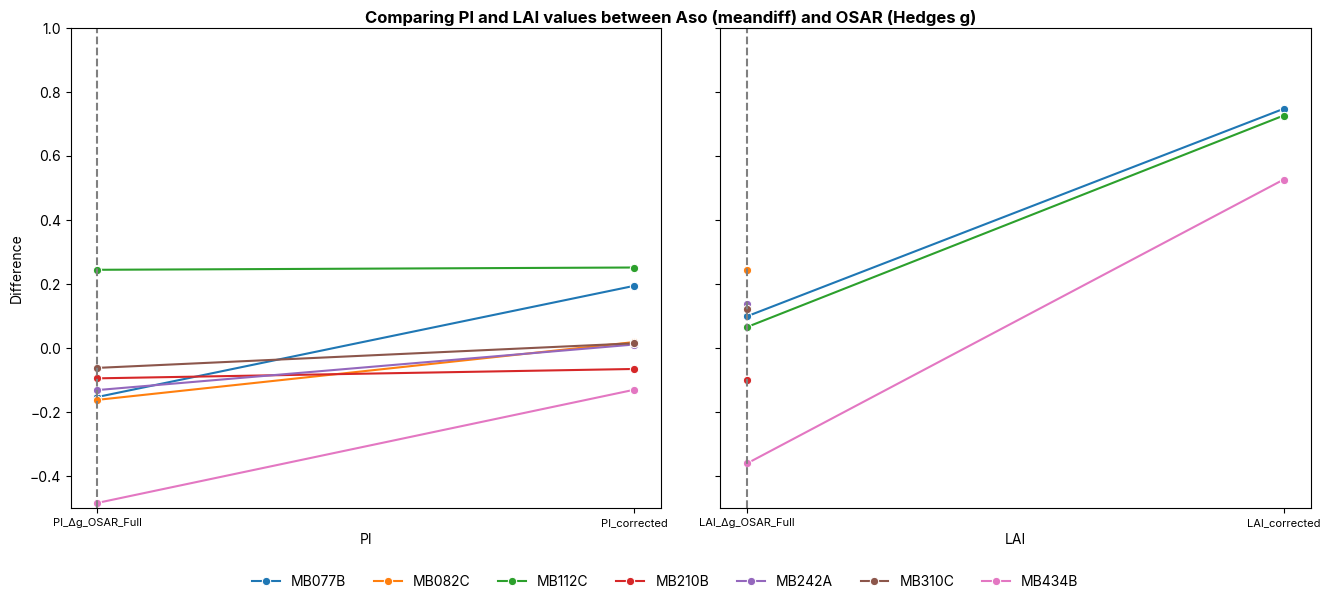

In [254]:
asovsme_pi = asovsme[['MBON', 'PI_Δg_OSAR_Full', 'PI_corrected']].melt(id_vars='MBON', var_name='PI', value_name='Difference')
asovsme_lai = asovsme[["MBON", 'LAI_Δg_OSAR_Full','LAI_corrected']].melt(id_vars='MBON', var_name='LAI', value_name='Difference')

figline, axes = plt.subplots(1,2, figsize=(16,6), sharey = True)
ax=axes.flatten()
sns.lineplot(x = "PI", y = "Difference", hue = "MBON", data=asovsme_pi,marker='o', ax=axes[0])
sns.lineplot(x = "LAI", y = "Difference", hue = "MBON", data=asovsme_lai, marker='o',ax=axes[1])

ax[0].axvline(x='PI_Δg_OSAR_Full', color='gray', linestyle='--')
ax[1].axvline(x='LAI_Δg_OSAR_Full', color='gray', linestyle='--')

axes[0].set_ylim(-0.5, 1)
ax[0].get_legend().remove()
ax[1].get_legend().remove()

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0, fontsize = 8)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0, fontsize = 8)

plt.subplots_adjust(top=0.95, wspace=0.1, bottom = 0.15)
figline.suptitle("Comparing PI and LAI values between Aso (meandiff) and OSAR (Hedges g)", weight = "bold")
handles, labels = ax[0].get_legend_handles_labels()
figline.legend(handles, labels, loc='lower center', ncol=len(labels), frameon=False)


In [ ]:
asovsme_pi = asovsme[['MBON', 'PI_Δg_OSAR_Full', 'PI_corrected']].set_index('MBON')
asovsme_lai = asovsme[["MBON", 'LAI_Δg_OSAR_Full','LAI_corrected']].set_index('MBON').apply(pd.to_numeric, errors='coerce')

,MBON,PI,Difference
0,MB077B,PI_Δg_OSAR_Full,-0.153291
1,MB082C,PI_Δg_OSAR_Full,-0.162254
2,MB112C,PI_Δg_OSAR_Full,0.244231
3,MB210B,PI_Δg_OSAR_Full,-0.094999
4,MB242A,PI_Δg_OSAR_Full,-0.131655
5,MB310C,PI_Δg_OSAR_Full,-0.062308
6,MB434B,PI_Δg_OSAR_Full,-0.484317
7,MB077B,PI_corrected,0.194063
8,MB082C,PI_corrected,0.018334
9,MB112C,PI_corrected,0.251366


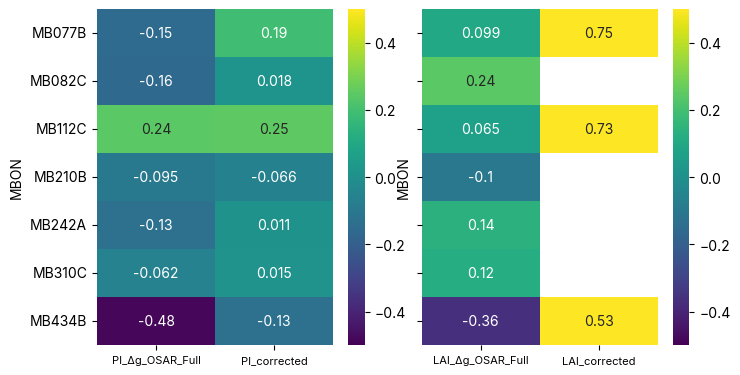

In [259]:
fig, axes = plt.subplots(1,2, figsize=(8,4), sharey = True)
ax=axes.flatten()
asovsme_pi = asovsme[['MBON', 'PI_Δg_OSAR_Full', 'PI_corrected']].set_index('MBON')
asovsme_lai = asovsme[["MBON", 'LAI_Δg_OSAR_Full','LAI_corrected']].set_index('MBON').apply(pd.to_numeric, errors='coerce')

sns.heatmap(asovsme_pi , annot=True, cmap='viridis', vmin = -0.5, vmax = 0.5, ax=axes[0])
sns.heatmap(asovsme_lai , annot=True, cmap='viridis', vmin = -0.5, vmax = 0.5, ax=axes[1])

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0, fontsize = 8)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0, fontsize = 8)
# plt.title("MBON PI and LAI values comparing Aso and OSAR", weight = 'bold', fontsize = 14)
# plt.savefig(filesavedir + "MBON PI and LAI values between ASO and OSAR (deltag).png", dpi=1200)
plt.savefig(filesavedir + "MBON PI and LAI values between ASO and OSAR (full_deltag).svg")
plt.subplots_adjust(top=0.95, wspace=0.1)
plt.show()

In [233]:
##averaging the deltag

pi_cols = [col for col in totalcompmodel.columns if 'PI_Δg_OSAR' in col]
totalcompmodel['PI_OSAR_mean'] = totalcompmodel[pi_cols].mean(axis=1)
averagedpi = pd.concat([totalcompmodel['MBON'], totalcompmodel['PI_OSAR_mean']], axis=1).reset_index(drop=True)

lai_cols = [col for col in totalcompmodel.columns if 'Light Attraction Index_Δg_OSAR' in col]
totalcompmodel['LAI_OSAR_mean'] = totalcompmodel[lai_cols].mean(axis=1)
averagedlai = pd.concat([totalcompmodel['MBON'], totalcompmodel['LAI_OSAR_mean']], axis=1).reset_index(drop=True)

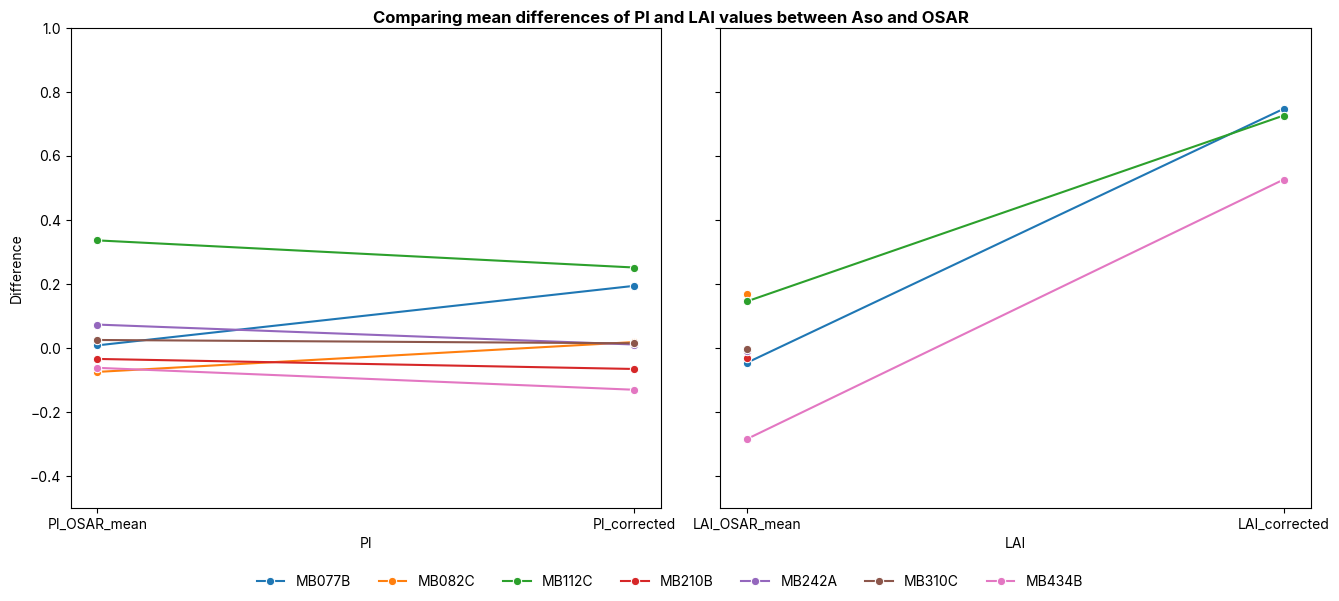

In [240]:
averaged_combined_pi = averagedpi.merge(aso_corrected[['MBON','PI_corrected']], on="MBON", how="inner").melt(id_vars='MBON', var_name='PI', value_name='Difference')
averaged_combined_lai = averagedlai.merge(aso_corrected[['MBON','LAI_corrected']], on="MBON", how="inner").melt(id_vars='MBON', var_name='LAI', value_name='Difference')

figline, axes = plt.subplots(1,2, figsize=(16,6), sharey = True)
ax=axes.flatten()
sns.lineplot(x = "PI", y = "Difference", hue = "MBON", data=averaged_combined_pi,marker='o', ax=axes[0])
sns.lineplot(x = "LAI", y = "Difference", hue = "MBON", data=averaged_combined_lai, marker='o',ax=axes[1])


axes[0].set_ylim(-0.5, 1)
ax[0].get_legend().remove()
ax[1].get_legend().remove()

plt.subplots_adjust(top=0.95, wspace=0.1, bottom = 0.15)
figline.suptitle("Comparing mean differences of PI and LAI values between Aso and OSAR", weight = "bold")
handles, labels = ax[0].get_legend_handles_labels()
figline.legend(handles, labels, loc='lower center', ncol=len(labels), frameon=False)


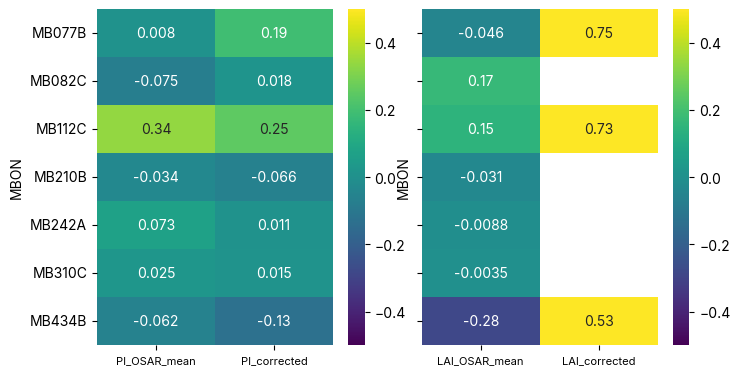

In [253]:
heatmap_pi = averagedpi.merge(aso_corrected[['MBON','PI_corrected']], on="MBON", how="inner").set_index('MBON')
heatmap_lai = averagedlai.merge(aso_corrected[['MBON','LAI_corrected']], on="MBON", how="inner").set_index('MBON').apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(1,2, figsize=(8,4), sharey = True)
ax=axes.flatten()

sns.heatmap(heatmap_pi, annot=True, cmap='viridis', vmin = -0.5, vmax = 0.5, ax=axes[0])
sns.heatmap(heatmap_lai, annot=True, cmap='viridis', vmin = -0.5, vmax = 0.5, ax=axes[1])

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0, fontsize = 8)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0, fontsize = 8)
# plt.title("MBON PI and LAI values comparing Aso and OSAR", weight = 'bold', fontsize = 14)
# plt.savefig(filesavedir + "MBON PI and LAI values between ASO and OSAR (deltag).png", dpi=1200)
plt.savefig(filesavedir + "MBON PI and LAI values between ASO and OSAR (averaged_deltag).svg")
plt.subplots_adjust(top=0.95, wspace=0.1)
plt.show()

## meandiff for sure

In [61]:
responder = "Chrimson2"
compiled = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\"+ filedate + "_" + responder + "_totalcompilation.csv"
dfcompiled= pd.read_csv(compiled, index_col=0)
dfcompiled.replace([np.inf, -np.inf], np.nan, inplace=True)
dfcompiled.rename(columns={'driver': 'MBON'}, inplace = True)
dfcompiled=dfcompiled[dfcompiled['MBON'].isin(['MB077B', 'MB082C','MB112C','MB210B','MB242A','MB310C','MB434B'])]

In [104]:
def meandiff_calculation_for_pi_lai(df, condition_name, parameters):
    totaldf = pd.DataFrame()
    for n in df['MBON'].unique().tolist():
        tempdf = pd.DataFrame()
        tempdf['MBON'] = [n]
        for parameter in parameters:
            dbfeature = dabest.load(df[(df['MBON'] == n)].reset_index(drop=True), idx=("Sibling", "Offspring"),x="status", y=parameter)
            tempdf[parameter + "_" + condition_name]= [float(dbfeature.mean_diff.statistical_tests.difference)]
        totaldf = pd.concat([totaldf, tempdf]).reset_index(drop=True)
            
    return totaldf

In [106]:
# Define the four conditions
conditions = {
    'Eighth': dfcompiled['light_intensity'] == 'Eighth',
    'Quarter': dfcompiled['light_intensity'] == 'Quarter',
    'Half': dfcompiled['light_intensity'] == 'Half',
    'Full': dfcompiled['light_intensity'] == 'Full'
}

allconditions = []

for condition_name, condition_filter in conditions.items():
    df1 = dfcompiled[condition_filter].loc[:,['MBON','light_intensity','status','pi_smoothed_Pattern 01',                                                
                                               'light_attraction_index_Pattern 01']].reset_index(drop=True)
    
    parameters= ["pi_smoothed_Pattern 01", "light_attraction_index_Pattern 01"]
    singlecondition = meandiff_calculation_for_pi_lai(df1, condition_name, parameters)
    allconditions.append(singlecondition)

big_df = allconditions[0]
for df in allconditions[1:]:
    big_df = pd.merge(big_df, df, on='MBON', how='inner')

big_df



,MBON,pi_smoothed_Pattern 01_Eighth,light_attraction_index_Pattern 01_Eighth,pi_smoothed_Pattern 01_Quarter,light_attraction_index_Pattern 01_Quarter,pi_smoothed_Pattern 01_Half,light_attraction_index_Pattern 01_Half,pi_smoothed_Pattern 01_Full,light_attraction_index_Pattern 01_Full
0,MB077B,0.081946,-0.039290,0.162218,0.030580,-0.148805,-0.131484,-0.083540,0.056091
1,MB082C,0.104413,0.119029,-0.033657,0.072981,-0.153041,0.026078,-0.095005,0.117999
2,MB112C,0.156594,0.043619,0.181710,0.099512,0.238639,0.084791,0.164455,0.033881
3,MB210B,0.027947,0.031618,-0.123241,-0.059666,0.066609,0.010878,-0.066012,-0.059843
4,MB242A,0.089374,-0.023543,0.124826,-0.048774,0.006540,-0.011788,-0.078075,0.069696
5,MB310C,-0.011597,0.071210,-0.117918,-0.039456,0.163622,-0.025560,-0.062197,0.071712
6,MB434B,0.167708,-0.149557,0.043565,-0.021490,-0.082630,-0.241612,-0.319026,-0.238794


<Axes: ylabel='MBON'>

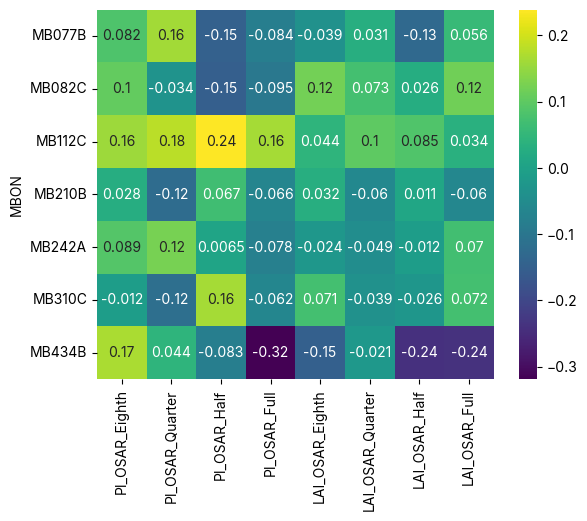

In [115]:
big_df.columns = big_df.columns.str.replace("pi_smoothed_Pattern 01", "PI_OSAR")
big_df.columns = big_df.columns.str.replace("light_attraction_index_Pattern 01", "LAI_OSAR")

meandiff = big_df.set_index("MBON")
meandiff = meandiff[['PI_OSAR_Eighth', 'PI_OSAR_Quarter','PI_OSAR_Half','PI_OSAR_Full',
                     'LAI_OSAR_Eighth','LAI_OSAR_Quarter','LAI_OSAR_Half', 'LAI_OSAR_Full']]
sns.heatmap(meandiff, annot=True, cmap='viridis')

## comparing the meandiffs

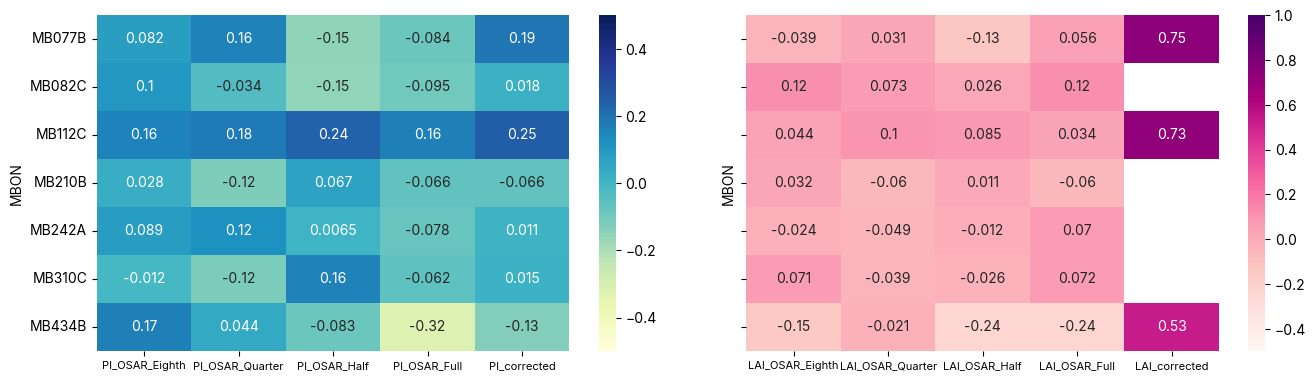

In [144]:
meandiffboth = meandiff.merge(aso_corrected, on="MBON", how="inner")
meandiffpi = meandiffboth[['MBON', 'PI_OSAR_Eighth', 'PI_OSAR_Quarter','PI_OSAR_Half','PI_OSAR_Full', 'PI_corrected']].set_index("MBON")
meandifflai = meandiffboth[["MBON", 'LAI_OSAR_Eighth','LAI_OSAR_Quarter','LAI_OSAR_Half', 'LAI_OSAR_Full','LAI_corrected']].set_index("MBON").apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(1,2, figsize=(16,4), sharey = True)
ax=axes.flatten()
sns.heatmap(meandiffpi, annot=True, cmap='YlGnBu', vmin = -0.5, vmax = 0.5, ax=axes[0])
sns.heatmap(meandifflai, annot=True, cmap='RdPu', vmin = -0.5, vmax = 1, ax=axes[1])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0, fontsize = 8)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0, fontsize = 8)
# plt.title("MBON PI and LAI values comparing Aso and OSAR", weight = 'bold', fontsize = 14)
# plt.savefig(filesavedir + "MBON PI and LAI values between ASO and OSAR (deltag).png", dpi=1200)
# plt.savefig(filesavedir + "MBON PI and LAI values between ASO and OSAR (deltag).svg")
plt.subplots_adjust(top=0.95, wspace=0.1)
plt.show()

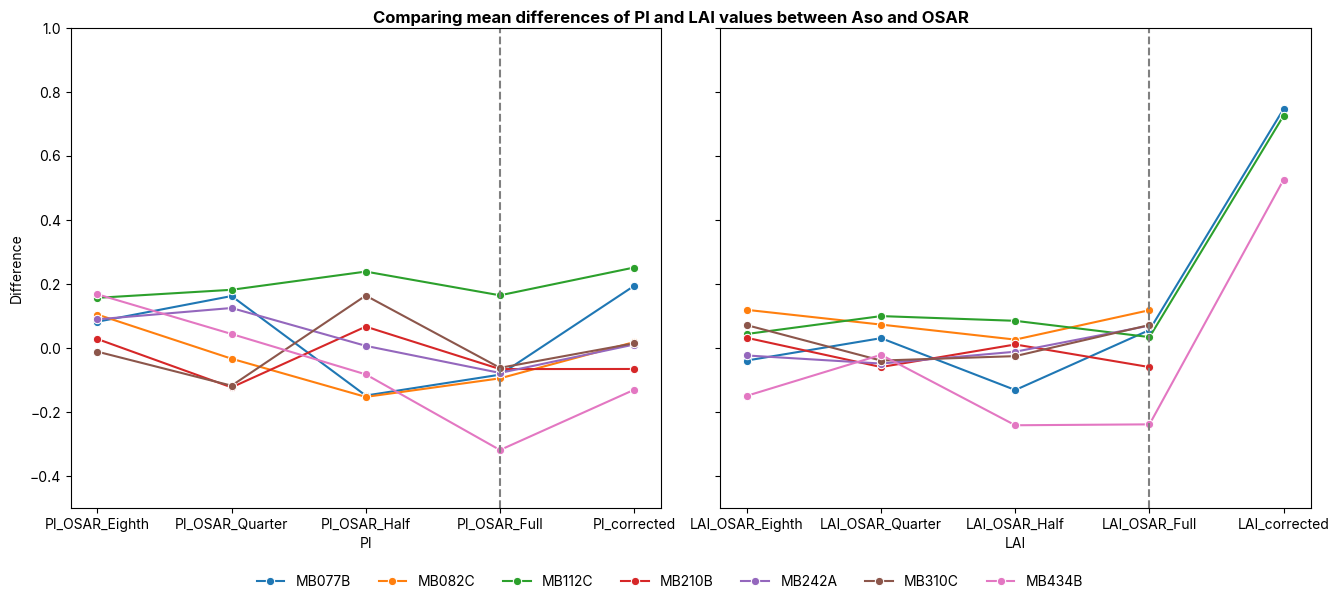

In [169]:
meandiffboth = meandiff.merge(aso_corrected, on="MBON", how="inner")
meandiffpi = meandiffboth[['MBON', 'PI_OSAR_Eighth', 'PI_OSAR_Quarter','PI_OSAR_Half','PI_OSAR_Full', 'PI_corrected']].melt(id_vars='MBON', var_name='PI', value_name='Difference')
meandifflai = meandiffboth[["MBON", 'LAI_OSAR_Eighth','LAI_OSAR_Quarter','LAI_OSAR_Half', 'LAI_OSAR_Full','LAI_corrected']].melt(id_vars='MBON', var_name='LAI', value_name='Difference')

figline, axes = plt.subplots(1,2, figsize=(16,6), sharey = True)
ax=axes.flatten()
sns.lineplot(x = "PI", y = "Difference", hue = "MBON", data=meandiffpi,marker='o', ax=axes[0])
sns.lineplot(x = "LAI", y = "Difference", hue = "MBON", data=meandifflai, marker='o',ax=axes[1])

ax[0].axvline(x='PI_OSAR_Full', color='gray', linestyle='--')
ax[1].axvline(x='LAI_OSAR_Full', color='gray', linestyle='--')

axes[0].set_ylim(-0.5, 1)
ax[0].get_legend().remove()
ax[1].get_legend().remove()

plt.subplots_adjust(top=0.95, wspace=0.1, bottom = 0.15)
figline.suptitle("Comparing mean differences of PI and LAI values between Aso and OSAR", weight = "bold")
handles, labels = ax[0].get_legend_handles_labels()
figline.legend(handles, labels, loc='lower center', ncol=len(labels), frameon=False)


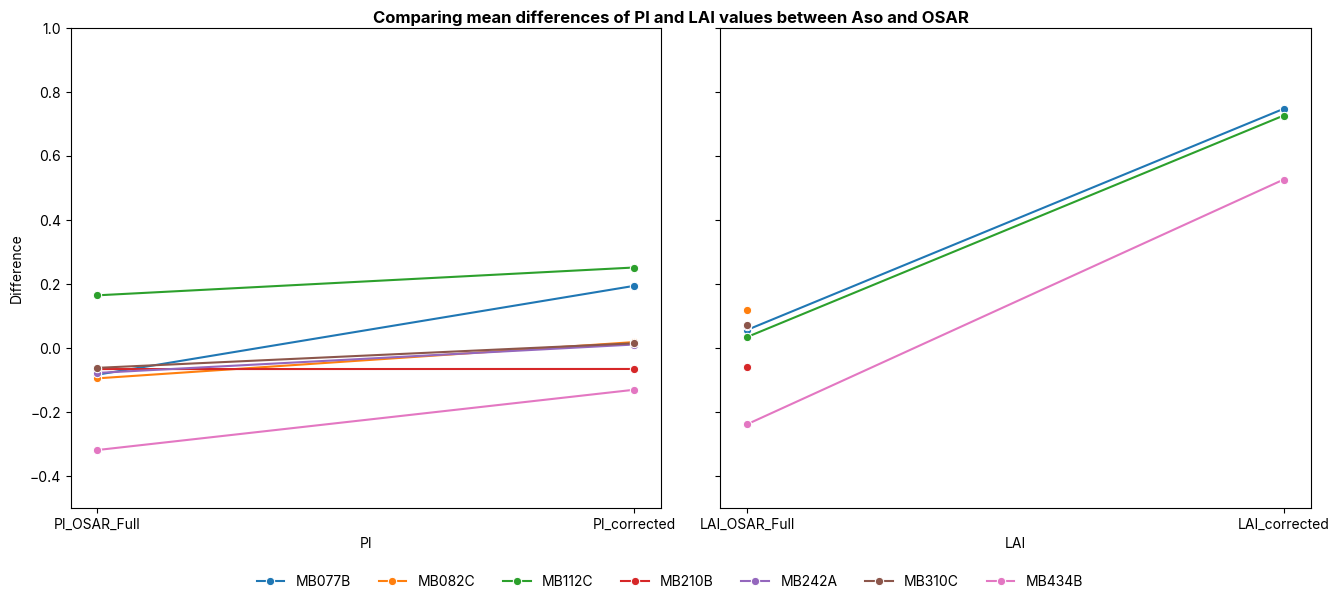

In [171]:
meandiffboth = meandiff.merge(aso_corrected, on="MBON", how="inner")
meandiffpi = meandiffboth[['MBON', 'PI_OSAR_Full', 'PI_corrected']].melt(id_vars='MBON', var_name='PI', value_name='Difference')
meandifflai = meandiffboth[["MBON", 'LAI_OSAR_Full','LAI_corrected']].melt(id_vars='MBON', var_name='LAI', value_name='Difference')

figline, axes = plt.subplots(1,2, figsize=(16,6), sharey = True)
ax=axes.flatten()
sns.lineplot(x = "PI", y = "Difference", hue = "MBON", data=meandiffpi,marker='o', ax=axes[0])
sns.lineplot(x = "LAI", y = "Difference", hue = "MBON", data=meandifflai, marker='o',ax=axes[1])


axes[0].set_ylim(-0.5, 1)
ax[0].get_legend().remove()
ax[1].get_legend().remove()

plt.subplots_adjust(top=0.95, wspace=0.1, bottom = 0.15)
figline.suptitle("Comparing mean differences of PI and LAI values between Aso and OSAR", weight = "bold")
handles, labels = ax[0].get_legend_handles_labels()
figline.legend(handles, labels, loc='lower center', ncol=len(labels), frameon=False)


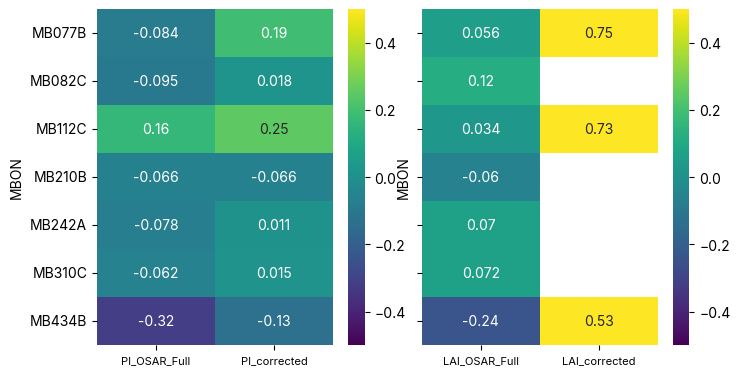

In [258]:
fig, axes = plt.subplots(1,2, figsize=(8,4), sharey = True)
ax=axes.flatten()
asovsme_pi = meandiffboth[['MBON', 'PI_OSAR_Full', 'PI_corrected']].set_index('MBON')
asovsme_lai = meandiffboth[['MBON', 'LAI_OSAR_Full', 'LAI_corrected']].set_index('MBON').apply(pd.to_numeric, errors='coerce')

sns.heatmap(asovsme_pi , annot=True, cmap='viridis', vmin = -0.5, vmax = 0.5, ax=axes[0])
sns.heatmap(asovsme_lai , annot=True, cmap='viridis', vmin = -0.5, vmax = 0.5, ax=axes[1])

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0, fontsize = 8)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0, fontsize = 8)
# plt.title("MBON PI and LAI values comparing Aso and OSAR", weight = 'bold', fontsize = 14)
# plt.savefig(filesavedir + "MBON PI and LAI values between ASO and OSAR (deltag).png", dpi=1200)
# plt.savefig(filesavedir + "MBON PI and LAI values between ASO and OSAR (averaged_deltag).svg")
plt.subplots_adjust(top=0.95, wspace=0.1)
plt.show()